# **CS 1810 Homework 2**
---
To account for potential version issues, try the following in your terminal:

1. Create a new environment with `python3 -m venv venv`
2. Activate that environment with `source venv/bin/activate`
3. Make sure the interpreter in the top right corner of your VSCode (or whatever you use to run your code is venv).
4. If you get a "install kernel" message, press it.
5. Run `pip install -r requirements.txt`
6. Run the remainder of this notebook.

Note that this is not necessary but can help prevent any issues due to package versions.

**The following notebook is meant to help you work through Problems 1 and 3 on Homework 2. You are by no means required to use it, nor are you required to fill out/use any of the boilerplate code/functions. You are welcome to implement the functions however you wish.**


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as c
import matplotlib.patches as mpatches
from scipy.special import expit as sigmoid
from scipy.special import softmax
from scipy.special import logsumexp
from scipy.stats import multivariate_normal as mvn
from T2_P3_TestCases import test_p3_softmax, test_p3_knn
from __future__ import annotations
from dataclasses import dataclass
from typing import Callable, Tuple
from matplotlib.colors import Normalize
import matplotlib.cm as cm

In [75]:
### Data for Problem 1
t_obs, y_obs = np.genfromtxt("data/planet-obs.csv", delimiter = ',').T
"""
Load and randomly partition the dataset into 10 folds for cross validation.

:param planet-obs.csv: CSV file with two columns (t, y)
:return:
    t_obs: list of length 10, each element is a numpy array of input values for one fold
    y_obs: list of length 10, each element is a numpy array of labels for one fold, shape (n_i, 1)
"""
N = len(t_obs)
indices = np.random.permutation(N)
folds = np.array_split(indices, 10)
t_folds = [t_obs[fold] for fold in folds]
y_folds = [y_obs[fold].reshape(-1, 1) for fold in folds]
t_obs = t_folds
y_obs = y_folds

### Data for Problem 3
data = pd.read_csv("data/hr.csv")
mapper = {
    "Automatically Rejected": 0,
    "Require Guarantor": 1,
    "Automatically Accepted": 2
}
data['Type'] = data['Type'].map(mapper)
X_applicants = data[['Debt to Income Ratio', 'Credit Score']].values

# transformation as described in problem statement
def transform(X):
  X = np.stack((X[:,0]*20/0.7-7.5, X[:,1]/140 - (500/140+0.5)), axis=1)
  return X
# Transformation
X_applicants = transform(X_applicants)
y_applicants = data['Type'].values

# Problem 1

## Problem 1 Subpart 1

In [76]:
def basis1(t):
    return np.stack([np.ones(len(t)), t], axis=1)

def basis2(t):
    """
    Transform t into your chosen basis 

    :param t: a numpy array of values to transform. Shape is (n,)
    :return: a 2D array in which each row corresponds to a basis transformation of
             an input value. Shape should be (n x d)
    """
    return np.stack([np.ones(len(t)), t, t**2], axis=1)

def basis3(t):
    """
    Transform t into another one of your chosen basis

    :param t: a numpy array of values to transform. Shape is (n,)
    :return: a 2D array in which each row corresponds to a basis transformation of
             an input value. Shape should be (n x d)
    """
    return np.stack([np.ones(len(t)), np.sin(t), np.cos(t)], axis=1)


In [77]:
class LogisticRegressor:
    def __init__(self, eta, runs):
        self.eta = eta
        self.runs = runs
        self.W = None

    def fit(self, x, y, w_init):
        """
        Optimize the weights W to minimize the negative log-likelihood by using gradient descent

        :param x: a 2D numpy array of transformed feature values. Shape is (n x d), where d depends on your basis functions
        :param y: a 2D numpy array of output values. Shape is (n x 1)
        :param w_init: a 2D numpy array that initializes the weights. Shape is (d x 1)
        :return: None
        """
        # Keep this for the autograder
        self.W = w_init
        for _ in range(self.runs):
            preds = self.predict(x)
            grad = 1/len(x) * x.T @ (preds - y)
            self.W -= self.eta * grad

    def predict(self, x):
        """
        Predict classification probability of transformed input x

        :param x: a 2D numpy array of transformed feature values. Shape is (n x d), where d depends on your basis functions
        :return: a 2D numpy array of predicted probabilities given current weights. Shape should be (n x 1)
        """
        return 1 / (1 + np.exp(-x @ self.W))

## Problem 1 Part 7

Below we have written function signatures and descriptions that you may consider following to implement cross-validation. Of course, feel free to implement things as you please, as long as you implement what is requested by the question.

In [89]:
import numpy as np

def stack_folds(folds):
    """
    Concatenate a list of fold arrays along the first axis.

    :param folds: list of numpy arrays, each with shape (n_i, d)
    :return: numpy array with shape (sum_i n_i, d)
    """
    return np.concatenate(folds, axis=0)

def probs_to_labels(p, threshold=0.5):
    """
    Convert predicted probabilities into {0,1} labels using a threshold.

    :param p: numpy array of probabilities, shape (n,1) or (n,)
    :param threshold: float in [0,1], decision threshold
    :return: numpy array of integer labels in {0,1}, shape (n,1)
    """
    return (p >= threshold).astype(int)

def compute_basis_folds(t_obs, basis_fn):
    """
    Apply a basis function to each fold once.

    :param t_obs: list of numpy arrays, each fold input, shape (n_i, 1) or (n_i,)
    :param basis_fn: function mapping t -> X (transformed features)
    :return: list of numpy arrays X_obs, where X_obs[i] = basis_fn(t_obs[i])
             each X_obs[i] has shape (n_i, d)
    """
    return [basis_fn(t) for t in t_obs]

def classification_error(y_true, y_pred):
    """
    Compute average 0/1 classification error.

    :param y_true: numpy array of true labels, shape (n,1) or (n,)
    :param y_pred: numpy array of predicted labels, shape (n,1) or (n,)
    :return: float, fraction misclassified
    """
    return np.mean(y_true != y_pred)

def cross_validate_single_basis(t_obs, y_obs, basis_fn, k=10, eta=0.001, runs=1000, threshold=0.5):
    """
    Perform k-fold cross validation for ONE basis representation, using the provided fold split.

    Procedure:
      1) Transform each fold once using basis_fn
      2) For fold i:
           - train on all folds except i
           - validate on fold i
      3) Return the per-fold classification errors

    :param t_obs: list of length k, each entry is a numpy array of t values for fold i
    :param y_obs: list of length k, each entry is a numpy array of labels for fold i, shape (n_i,1)
    :param basis_fn: basis function used to transform t -> X
    :param k: int, number of folds (should match len(t_obs))
    :param eta: float, learning rate passed to LogisticRegressor
    :param runs: int, number of gradient steps/iterations passed to LogisticRegressor
    :param threshold: float, probability threshold for turning probs into labels
    :return: numpy array of fold errors, shape (k,)
    """
    X_obs = compute_basis_folds(t_obs, basis_fn)
    errors = []
    for i in range(k):
        X_train = stack_folds([X_obs[j] for j in range(k) if j != i])
        y_train = stack_folds([y_obs[j] for j in range(k) if j != i])
        X_val = X_obs[i]
        y_val = y_obs[i]
        
        model = LogisticRegressor(eta=eta, runs=runs)
        model.fit(X_train, y_train, np.zeros((X_train.shape[1], 1)))
        
        preds = probs_to_labels(model.predict(X_val), threshold)
        errors.append(classification_error(y_val, preds))
    
    return np.array(errors)


def run_cv_all_bases(t_obs, y_obs, bases, k=10, eta=0.001, runs=1000, threshold=0.5):
    """
    Convenience wrapper to run CV for multiple basis functions.

    :param t_obs: list of folds for t
    :param y_obs: list of folds for y
    :param bases: list of tuples (name, basis_fn)
    :param k: int, number of folds
    :param eta: float, learning rate
    :param runs: int, iterations
    :param threshold: float, probability threshold
    :return: dict mapping basis name -> numpy array of fold errors, shape (k,)
    """
    return {name: cross_validate_single_basis(t_obs, y_obs, fn, k, eta, runs, threshold) for name, fn in bases}
    
# Run the Cross Validation for the 3 Basis Functions 
bases = [("basis1", basis1), ("basis2", basis2), ("basis3", basis3)]
cv_results = run_cv_all_bases(t_obs, y_obs, bases, k=10, eta=0.001, runs=1000, threshold=0.5)

for name in cv_results:
    errs = cv_results[name]
    print(f"{name} fold errors:")
    print(errs)
    print(f"{name} average error (10-fold): {errs.mean():.6f}")
    print("-" * 60)

basis1 fold errors:
[0.46666667 0.53333333 0.46666667 0.53333333 0.6        0.43333333
 0.56666667 0.46666667 0.43333333 0.43333333]
basis1 average error (10-fold): 0.493333
------------------------------------------------------------
basis2 fold errors:
[0.33333333 0.4        0.33333333 0.56666667 0.3        0.3
 0.5        0.33333333 0.36666667 0.23333333]
basis2 average error (10-fold): 0.366667
------------------------------------------------------------
basis3 fold errors:
[0.23333333 0.2        0.26666667 0.4        0.16666667 0.26666667
 0.4        0.33333333 0.4        0.2       ]
basis3 average error (10-fold): 0.286667
------------------------------------------------------------


## Plotting Functions for Problem 1, Subpart 2

In [78]:
# Function to visualize prediction lines
# Takes as input last_x, last_y, [list of models], basis function, title
# last_x and last_y should specifically be the dataset that the last model
# in [list of models] was trained on
def visualize_prediction_lines(last_x, last_y, models, basis, title):
    # Plot setup
    green = mpatches.Patch(color='green', label='Ground truth model')
    black = mpatches.Patch(color='black', label='Mean of learned models')
    purple = mpatches.Patch(color='purple', label='Model learned from displayed dataset')
    plt.legend(handles=[green, black, purple], loc='lower right')
    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel('Observed')
    plt.axis([0, 6, -.1, 1.1]) # Plot ranges

    # Plot dataset that last model in models (models[-1]) was trained on
    cmap = c.ListedColormap(['r', 'b'])
    plt.scatter(last_x, last_y, c=last_y, cmap=cmap, linewidths=1, edgecolors='black')

    # Plot models
    X_pred = np.linspace(0, 6, 1000)
    X_pred_transformed = basis(X_pred)

    ## Ground truth model
    plt.plot(X_pred, np.cos(1.1*X_pred + 1) * 0.4 + 0.5, 'g', linewidth=5)

    ## Individual learned logistic regressor models
    Y_hats = []
    for i in range(len(models)):
        model = models[i]
        Y_hat = model.predict(X_pred_transformed)
        Y_hats.append(Y_hat)
        if i < len(models) - 1:
            plt.plot(X_pred, Y_hat, linewidth=.3)
        else:
            plt.plot(X_pred, Y_hat, 'purple', linewidth=3)

    # Mean / expectation of learned models over all datasets
    plt.plot(X_pred, np.mean(Y_hats, axis=0), 'k', linewidth=5)

    plt.savefig('img_output/' + title + '.png')
    plt.show()

/var/folders/g5/n3b573ds69x6kcdgvy2sx7g00000gn/T/ipykernel_37816/1031064685.py:30: RuntimeWarning: divide by zero encountered in matmul
  return 1 / (1 + np.exp(-x @ self.W))
/var/folders/g5/n3b573ds69x6kcdgvy2sx7g00000gn/T/ipykernel_37816/1031064685.py:30: RuntimeWarning: overflow encountered in matmul
  return 1 / (1 + np.exp(-x @ self.W))
/var/folders/g5/n3b573ds69x6kcdgvy2sx7g00000gn/T/ipykernel_37816/1031064685.py:30: RuntimeWarning: invalid value encountered in matmul
  return 1 / (1 + np.exp(-x @ self.W))


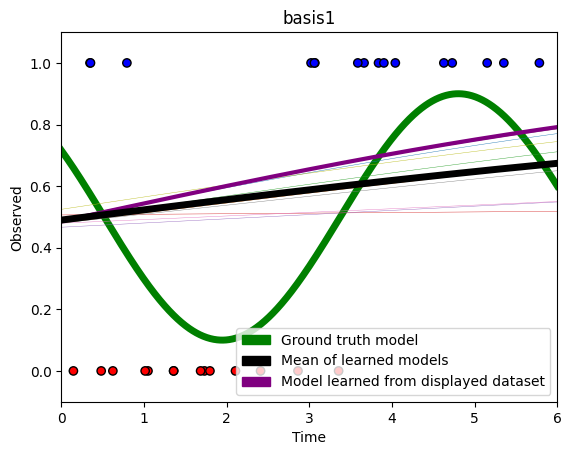

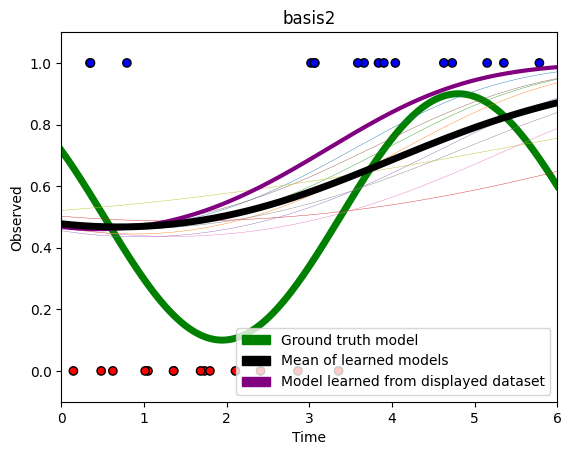

Classification probabilities for t = 0.1: 0.5238553579681556, t = 3.2: 0.5049809857043455
Model variances for t = 0.1: 0.0004896487622611768, t = 3.2: 0.0008114505882048154


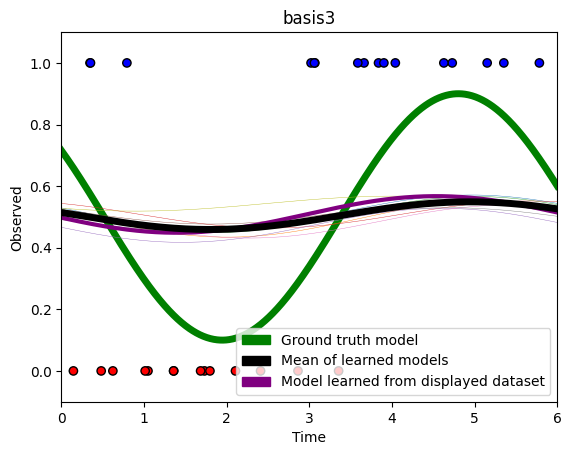

In [79]:
def plot_results(basis, title):
    eta = 0.001
    runs = 1000

    # For Problem 1.4
    test_points_1 = []
    test_points_2 = []
    t1 = basis(np.array([0.1]))
    t2 = basis(np.array([3.2]))

    all_models = []
    for i in range(10):
        x, y = t_obs[i], y_obs[i]
        x_transformed = basis(x)
        model = LogisticRegressor(eta=eta, runs=runs)
        model.fit(x_transformed, y, np.zeros((x_transformed.shape[1], 1)))
        all_models.append(model)

        if basis == basis3:
            # extract values from (1 x 1) array
            pred_1 = model.predict(t1)[0, 0]
            pred_2 = model.predict(t2)[0, 0]
            if i == 0:
                print(f"Classification probabilities for t = 0.1: {pred_1}, t = 3.2: {pred_2}")
            test_points_1.append(pred_1)
            test_points_2.append(pred_2)

    if basis == basis3:
        print(f"Model variances for t = 0.1: {np.var(test_points_1)}, t = 3.2: {np.var(test_points_2)}")
    visualize_prediction_lines(x, y, all_models, basis, title)

plot_results(basis1, 'basis1')
plot_results(basis2, 'basis2')
plot_results(basis3, 'basis3')

## Problem 1, Subpart 6

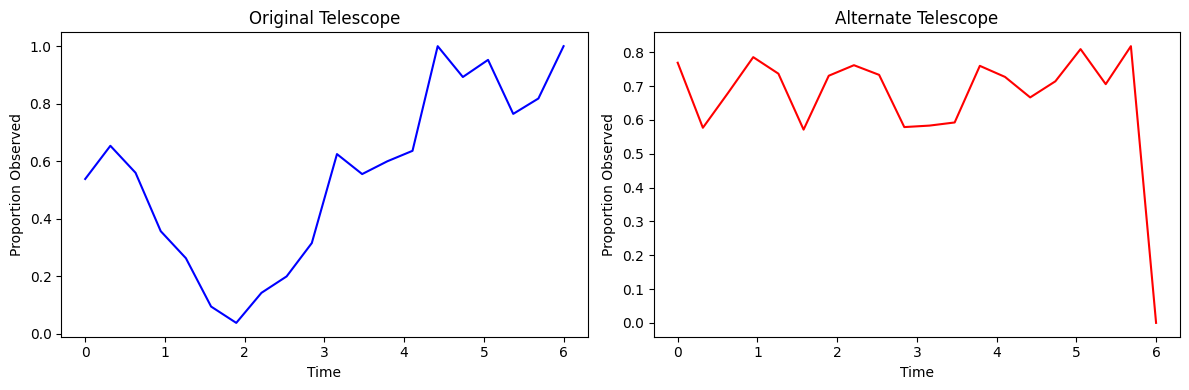

In [85]:
t_orig, y_orig = np.genfromtxt("data/planet-obs.csv", delimiter=',').T
_, t_alt, y_alt = np.genfromtxt("data/planet-obs-alternate.csv", delimiter=',', skip_header=1).T

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t_stamps = np.linspace(0, 6, 20)
orig_means = [y_orig[np.abs(t_orig - t) < 0.2].mean() for t in t_stamps]
alt_means = [y_alt[np.abs(t_alt - t) < 0.2].mean() for t in t_stamps]

axes[0].plot(t_stamps, orig_means, color='blue')
axes[0].set_title('Original Telescope')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Proportion Observed')

axes[1].plot(t_stamps, alt_means, color='red')
axes[1].set_title('Alternate Telescope')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Proportion Observed')

plt.tight_layout()
plt.savefig('img_output/1.6.png')
plt.show()

# Problem 3

In [1]:
class GaussianGenerativeModel:
    def __init__(self, is_shared_covariance=False):
        self.is_shared_covariance = is_shared_covariance

    def fit(self, X, y):
        """
        Compute the means and (shared) covariance matrix of the data. Compute the prior over y.

        :param X: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :param y: a 1D numpy array of target values (Automatically Rejected=0, Require Guarantor=1, Automatically Accepted=2).
        :return: None
        """

        self.classes = np.unique(y)
        self.K = len(self.classes)
        n = len(X)

        self.pi = np.array([np.sum(y==k)/n for k in self.classes])

        self.means = np.array([X[y == k].mean(axis=0) for k in self.classes])

        if self.is_shared_covariance:
            self.cov = np.zeros((X.shape[1], X.shape[1]))
            for idx, k in enumerate(self.classes):
                residuals = X[y == k] - self.means[idx]
                self.cov += residuals.T @ residuals
            self.cov /= n
        else:
            self.covs = []
            for idx, k in enumerate(self.classes):
                residuals = X[y == k] - self.means[idx]
                self.covs.append(residuals.T @ residuals / np.sum(y == k))

    def predict(self, X_pred):
        """
        Predict classes of points given feature values in X_pred

        :param X_pred: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :return: a 1D numpy array of predicted classes (Automatically Rejected=0, Require Guarantor=1, Automatically Accepted=2).
                 Shape should be (n,)
        """
        return np.argmax(self.predict_proba(X_pred), axis=1)

    def predict_proba(self, X_pred):
        n = len(X_pred)
        log_joint = np.zeros((n, self.K))
        
        for idx, _ in enumerate(self.classes):
            cov = self.cov if self.is_shared_covariance else self.covs[idx]
            log_joint[:, idx] = mvn.logpdf(X_pred, mean=self.means[idx], cov=cov) + np.log(self.pi[idx])
        
        return softmax(log_joint, axis=1)

    def negative_log_likelihood(self, X, y):
        """
        Given the data X, use previously calculated class means and covariance matrix to
        calculate the negative log likelihood of the data
        """

        pred_probs = self.predict_proba(X)
        true_class_probs = pred_probs[np.arange(len(y)), y]
        return -np.sum(np.log(true_class_probs))

In [10]:
class SoftmaxRegression:
    def __init__(self, eta, lam, verbose=True):
        self.eta = eta
        self.lam = lam
        self.W = None
        self.verbose = verbose

    # Some helper functions may go here:

    # YOUR CODE HERE
    pass

    def fit(self, X, y):
        """
        Fit the weights W of softmax regression using gradient descent with L2 regularization
        Use the results from Problem 2 to find an expression for the gradient
        
        :param X: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :param y: a 1D numpy array of target values (Automatically Rejected=0, Require Guarantor=1, Automatically Accepted=2).
        :return: None
        """
        # YOUR CODE HERE
        pass

    # Input is (n x 2) array
    def predict(self, X_pred):
        """
        Predict classes of points given feature values in X_pred
        
        :param X_pred: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :return: a 1D numpy array of predicted classes (Automatically Rejected=0, Require Guarantor=1, Automatically Accepted=2).
                 Shape should be (n,)
        """
        # YOUR CODE HERE
        pass

    # Input is (n x 2) array
    def predict_proba(self, X_pred):
        """    
        Predict classification probabilities of points given feature values in X_pred
        
        :param X_pred: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :return: a 2D numpy array of predicted class probabilities (Automatically Rejected=index 0, Require Guarantor=index 1, Automatically Accepted=index 2).
                 Shape should be (n x 3)
        """
        # YOUR CODE HERE
        pass

In [11]:
class KNNClassifier:
    def __init__(self, k):
        self.X = None
        self.y = None
        self.K = k

    # Helper functions go here: 

    # YOUR CODE HERE
    pass

    def fit(self, X, y):
        """
        In KNN, "fitting" can be as simple as storing the data, so this has been written for you.
        If you'd like to add some preprocessing here without changing the inputs, feel free,
        but this is completely optional.
        """
        self.X = X
        self.y = y

    def predict(self, X_pred_many):
        """
        Predict classes of points given feature values in X_pred
        
        :param X_pred: a 2D numpy array of (transformed) feature values. Shape is (n x 2)
        :return: a 1D numpy array of predicted classes (Automatically Rejected=0, Require Guarantor=1, Automatically Accepted=2).
                 Shape should be (n,)
        """
        # YOUR CODE HERE
        pass

In [12]:
def phi(X):
    """
    Transform [x_1, x_2] into basis [ln(x_1 + 10), x_2^2]

    :param t: a 2D numpy array of values to transform. Shape is (n x 2)
    :return: a 2D array in which each row corresponds to a basis transformation of
             an input value. Shape should be (n x 2)
    """
    # YOUR CODE HERE
    pass

## Plotting Function for Problem 3, Subpart 1

In [13]:
# Visualize the decision boundary that a model produces
def visualize_boundary(model, X, y, title, basis=None, width=10):
    # Create a grid of points
    x_min, x_max = min(X[:, 0]-width*0.15), max(X[:, 0]+width*0.15)
    y_min, y_max = min(X[:, 1]-width*0.2), max(X[:, 1]+width*0.2)
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.05),
        np.arange(y_min, y_max, 0.05)
    )

    # Flatten the grid so the values match spec for self.predict
    xx_flat = xx.flatten()
    yy_flat = yy.flatten()
    X_pred = np.vstack((xx_flat, yy_flat)).T

    if basis is not None:
        X_pred = basis(X_pred)

    # Get the class predictions
    Y_hat = model.predict(X_pred)
    Y_hat = Y_hat.reshape((xx.shape[0], xx.shape[1]))

    # Visualize them.
    cmap = c.ListedColormap(['r', 'b', 'g'])
    plt.figure()
    plt.title(title)
    plt.xlabel('Debt to Income Ratio')
    plt.ylabel('Credit Score')

    ticks = np.transpose(np.array([[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7],
                                   [300, 400, 500, 600, 700, 800, 900, 1000]]))
    transformed_ticks = transform(ticks)


    plt.xticks(transformed_ticks[:,0],
               ticks[:,0])
    plt.yticks(transformed_ticks[:,1],
               ticks[:,1])
    plt.pcolormesh(xx, yy, Y_hat, cmap=cmap, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, linewidths=1,
                edgecolors='black')

    # Adding a legend and a title
    red = mpatches.Patch(color='red', label='Automatically Rejected')
    blue = mpatches.Patch(color='blue', label='Require Guarantor')
    green = mpatches.Patch(color='green', label='Automatically Accepted')
    plt.legend(handles=[red, blue, green])

    # Saving the image to a file, and showing it as well
    plt.savefig('img_output/' + title + '.png')
    plt.show()

## Problem 3, Subpart 1

In [14]:
# Fit models and visualize their decision boundaries

# YOUR CODE HERE
pass

In [ ]:
# You may test your models' correctness using test_p3_softmax and test_p3_knn
# See T2_P3_TestCases.py for how the test functions are written
# YOUR CODE HERE
pass

## Problem 3, Subpart 2

In [16]:
# Predicting for new applicant
point = transform(np.array([(0.32, 350)]))
point

# YOUR CODE HERE
pass

## Problem 4

In [17]:
# -----------------------------
# Synthetic 2D regression problem
# -----------------------------

def make_problem(n: int = 120, seed: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)

    # correlated + differently-scaled features -> ravine in loss
    x0 = rng.normal(size=n)
    x1 = 0.12 * x0
    X = np.stack([x0, x1], axis=1)
    w_true = np.array([300.0, -200])
    y = X @ w_true + 0.12 * rng.normal(size=n)

    # standardize
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
    y = y - y.mean()
    return X, y

In [18]:
# -----------------------------
# Losses + gradients
# -----------------------------
def loss_linear(X, y, w):
    """Linear regression loss: L(w) = (1/2n) * sum_i (x_i^T w - y_i)^2"""
    # YOUR CODE HERE
    pass

def grad_linear(X, y, w):
    """Gradient of the linear regression loss w.r.t. w."""
    # YOUR CODE HERE
    pass

def mse(X, y, w):
    """Mean squared error (no 1/2 factor). Used for plotting."""
    # YOUR CODE HERE
    pass

def loss_ridge(X, y, w, lam):
    """Ridge loss: linear loss + (lambda/2) * ||w||^2"""
    # YOUR CODE HERE
    pass

def grad_ridge(X, y, w, lam):
    """Gradient of ridge loss: grad_linear + lambda * w"""
    # YOUR CODE HERE
    pass

In [19]:
# -----------------------------
# Optimizers (stateful)
# -----------------------------
@dataclass
class MomState:
    v: np.ndarray

def sgd_step(w, g, lr, state=None):
    """SGD update: w_{t+1} = w_t - lr * g_t"""
    # TODO: return the updated weights and None for state
    """
    Returns:
        (w_new, state)
    In this case, state is not used, but we return None for consistency with the other optimizers.
    """
    # YOUR CODE HERE
    pass

def mom_step(w, g, lr, beta, state: MomState | None):
    """
    Momentum update:
        v_{t+1} = beta * v_t + g_t
        w_{t+1} = w_t - lr * v_{t+1}

    Args:
        w:     current weights
        g:     current gradient
        lr:    learning rate
        beta:  momentum coefficient (e.g. 0.9)
        state: MomState carrying the velocity vector (None on first call)

    Returns:
        (w_new, state)
    """
    # YOUR CODE HERE
    pass

@dataclass
class AdamState:
    m: np.ndarray
    v: np.ndarray
    t: int

def adam_step(w, g, lr, beta1, beta2, eps, state: AdamState | None):
    """
    Adam update:
        m_t = beta1 * m_{t-1} + (1 - beta1) * g_t
        v_t = beta2 * v_{t-1} + (1 - beta2) * g_t^2
        m_hat = m_t / (1 - beta1^t)        # bias correction
        v_hat = v_t / (1 - beta2^t)        # bias correction
        w_{t+1} = w_t - lr * m_hat / (sqrt(v_hat) + eps)

    Args:
        w:     current weights
        g:     current gradient
        lr:    learning rate
        beta1: decay rate for first moment  (e.g. 0.9)
        beta2: decay rate for second moment (e.g. 0.999)
        eps:   small constant for numerical stability
        state: AdamState (None on first call)

    Returns:
        (w_new, state)
    """
    # YOUR CODE HERE
    pass


## Graphing Code

In [20]:
def contour_panel(
    ax,
    title,
    loss_fn: Callable[[np.ndarray], float],
    path: np.ndarray,
    both_opt: tuple = None
):
    # ----------------------------------
    # Include optima in plotting window
    # ----------------------------------
    key_pts = path

    if both_opt is not None:
        opt_1, opt_2 = both_opt

        extra_pts = []
        if opt_1 is not None:
            extra_pts.append(opt_1.reshape(1, -1))
        if opt_2 is not None:
            extra_pts.append(opt_2.reshape(1, -1))

        if extra_pts:
            key_pts = np.vstack([path] + extra_pts)

    # ----------------------------------
    # Build contour grid
    # ----------------------------------
    pad_frac = 0.3
    w0_lo, w0_hi = 40, 300
    w1_lo, w1_hi = -75, 175
    #w0_lo, w0_hi = key_pts[:, 0].min(), key_pts[:, 0].max()
    #w1_lo, w1_hi = key_pts[:, 1].min(), key_pts[:, 1].max()

    w0_pad = pad_frac * max(w0_hi - w0_lo, 1.0)
    w1_pad = pad_frac * max(w1_hi - w1_lo, 1.0)

    w0s = np.linspace(w0_lo - w0_pad, w0_hi + w0_pad, 300)
    w1s = np.linspace(w1_lo - w1_pad, w1_hi + w1_pad, 300)

    W0, W1 = np.meshgrid(w0s, w1s)

    Z = np.zeros_like(W0)
    for i in range(Z.shape[0]):
        pts = np.stack([W0[i], W1[i]], axis=1)
        Z[i] = np.array([loss_fn(p) for p in pts])

    # ----------------------------------
    # Plot contours
    # ----------------------------------
    ax.contourf(W0, W1, Z, levels=40, cmap=cm.turbo)
    ax.contour(W0, W1, Z, levels=18, linewidths=0.7, cmap=cm.turbo)

    # ----------------------------------
    # Plot path
    # ----------------------------------
    ax.plot(path[:, 0], path[:, 1], c="white", linewidth=0.8, alpha=0.5)

    n_pts = len(path)
    norm = Normalize(vmin=0, vmax=n_pts - 1)
    cmap = cm.magma

    ax.scatter(
        path[:, 0],
        path[:, 1],
        c=np.arange(n_pts),
        cmap=cmap,
        norm=norm,
        s=35,
        edgecolor="white",
        linewidths=0.4,
        zorder=5,
    )

    # Start (square) and end (star)
    colors = cmap(norm(np.arange(n_pts)))
    ax.scatter(
        [path[0, 0]],
        [path[0, 1]],
        marker="s",
        s=120,
        c=[colors[0]],
        edgecolor="white",
        linewidths=1.5,
        zorder=6,
    )

    ax.scatter(
        [path[-1, 0]],
        [path[-1, 1]],
        marker="*",
        s=220,
        c=[colors[-1]],
        edgecolor="white",
        linewidths=1.5,
        zorder=6,
    )

    # ----------------------------------
    # Plot optima
    # ----------------------------------
    if both_opt is not None:
        opt_1, opt_2 = both_opt

        # Line of solutions: w1 = 276 - w0
        opt_line_x = np.linspace(70, 300, 500)
        opt_line_y = 276 - opt_line_x
        ax.plot(opt_line_x, opt_line_y, 'r--', linewidth=2, label = 'opt_1')


        if opt_2 is not None:
            ax.scatter(
                opt_2[0],
                opt_2[1],
                marker="x",
                s=160,
                c="blue",
                linewidths=3,
                label="opt_2",
                zorder=7,
            )

        ax.legend(fontsize=8)

    # ----------------------------------
    ax.set_title(title)
    ax.set_xlabel("w0")
    ax.set_ylabel("w1")

    ax.set_xlim(40, 300)
    ax.set_ylim(-75, 175)


In [21]:
# -----------------------------
# Run + record path
# -----------------------------
def run(
    grad_fn: Callable[[np.ndarray], np.ndarray],
    w0: np.ndarray,
    steps: int,
    stepper: Callable,
    stepper_kwargs: dict,
):
    w = w0.copy()
    path = [w.copy()]
    state = None
    for _ in range(steps):
        g = grad_fn(w)
        w, state = stepper(w, g, **stepper_kwargs, state=state)
        path.append(w.copy())
    return np.array(path)



In [22]:
X, y = make_problem(seed=0)
w_start = np.array([125.0, -25.0])

steps = 20
lam = 1

# OLS optimum (depends on w_true through the generated data)
w_opt_lin = np.linalg.lstsq(X, y, rcond=None)[0]
# Ridge closed-form optimum
I = np.eye(X.shape[1])
w_opt_rid = np.linalg.solve(X.T @ X / len(y) + lam * I, X.T @ y / len(y))

# Objective-specific functions (closures over X,y)
lin_loss = lambda w: loss_linear(X, y, w)
lin_grad = lambda w: grad_linear(X, y, w)

rid_loss = lambda w: loss_ridge(X, y, w, lam)
rid_grad = lambda w: grad_ridge(X, y, w, lam)

# Hyperparams tuned so the paths look distinct + stable
sgd_lr_lin = 0.12
mom_lr_lin = 0.04
adam_lr_lin = 20

sgd_lr_rid = 0.10
mom_lr_rid = 0.03
adam_lr_rid = 25

beta = 0.9
beta1, beta2, eps = 0.8, 0.8, 1e-8

# --- Linear paths ---
p_lin_sgd  = run(lin_grad, w_start, steps, sgd_step,  dict(lr=sgd_lr_lin))
p_lin_mom  = run(lin_grad, w_start, steps, mom_step,  dict(lr=mom_lr_lin, beta=beta))
p_lin_adam = run(lin_grad, w_start, steps, adam_step, dict(lr=adam_lr_lin, beta1=beta1, beta2=beta2, eps=eps))

# --- Ridge paths ---
p_rid_sgd  = run(rid_grad, w_start, steps, sgd_step,  dict(lr=sgd_lr_rid))
p_rid_mom  = run(rid_grad, w_start, steps, mom_step,  dict(lr=mom_lr_rid, beta=beta))
p_rid_adam = run(rid_grad, w_start, steps, adam_step, dict(lr=adam_lr_rid, beta1=beta1, beta2=beta2, eps=eps))

# --- Contour plots ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

both_opt = (w_opt_lin, w_opt_rid)

contour_panel(axes[0, 0], "Linear + SGD",          lin_loss, p_lin_sgd,  both_opt)
contour_panel(axes[0, 1], "Linear + Momentum",     lin_loss, p_lin_mom,  both_opt)
contour_panel(axes[0, 2], "Linear + Adam",         lin_loss, p_lin_adam, both_opt)

contour_panel(axes[1, 0], "Ridge + SGD",           rid_loss, p_rid_sgd,  both_opt)
contour_panel(axes[1, 1], "Ridge + Momentum",      rid_loss, p_rid_mom,  both_opt)
contour_panel(axes[1, 2], "Ridge + Adam",          rid_loss, p_rid_adam, both_opt)

plt.tight_layout()
plt.show()